# Statistical Analysis of ERPs

In [1]:
import numpy as np
import mne
from scipy.stats import ttest_1samp, t as t_dist
from matplotlib import pyplot as plt

## Utility Functions

In [2]:
def plot_cluster_topo(cluster, t, p, epochs):
    ch_inds, time_inds = _get_cluster_indices(cluster)
    t_map = t[time_inds, :].mean(axis=0)
    sig_times = epochs.times[time_inds]
    mask = np.zeros(t_map.shape, dtype=bool)
    mask[ch_inds] = True
    img, _ = mne.viz.plot_topomap(t_map, epochs.info, mask=mask, show=False, size=4)
    plt.title(f"p = {p.round(3)}, time: {sig_times[0]:.3f} - {sig_times[-1]:.3f} s")
    plt.colorbar(img, label="t-value", shrink=0.7)

def plot_cluster_channels(cluster, p, erf):
    ch_inds, time_inds = _get_cluster_indices(cluster)
    sig_times = epochs.times[time_inds]
    cluster_erf = erf.copy().pick(ch_inds)
    fig = cluster_erf.plot(show=False)
    ax = fig.axes[0]
    ymin, ymax = ax.get_ylim()
    ax.fill_between(erf.times[time_inds], y1=ymin, y2=ymax, color="red", alpha=0.2)
    ax.set_title(f"p = {p.round(3)}, time: {sig_times[0]:.3f} - {sig_times[-1]:.3f} s")

def _get_cluster_indices(cluster):
    time_inds, space_inds = cluster
    ch_inds = np.unique(space_inds)
    time_inds = np.unique(time_inds)
    return ch_inds, time_inds

class utils:
        _get_cluster_indices = _get_cluster_indices
        plot_cluster_channels = plot_cluster_channels 
        plot_cluster_topo = plot_cluster_topo

In most experiments, the scientific question involves **comparing responses between conditions**. To answer such questions rigorously, we need to go beyond visual inspection and apply formal statistical tests. The most common approach is the **null hypothesis significance test**: we assume that there is no difference between conditions and ask how likely it is to observe a difference at least as large as the one we measured by chance. By testing each channel at each time point, we can identify when the two conditions diverge.

But this introduces a **multiple comparisons problem**: some time points will reach significance by chance even when there is no real difference between conditions, producing false positives. To avoid an inflation of the false positive rate we have to adjust the significance threshold using procedures like the **Bonferroni correction**. However, with 100 channels and 300 time points we would have to conduct 30,000 tests, and standard correction procedures become overly conservative at this scale. The **permutation cluster test** addresses this by exploiting the spatial and temporal structure of the signal: rather than correcting for each time point and channel individually, it identifies contiguous clusters of significant time points and channels and tests whether their combined extent exceeds what would be expected under a null distribution estimated by permutation. This makes it both sensitive and well-calibrated for time series data.

Throughout this notebook, we apply these methods to MEG recordings from an auditory and visual stimulation experiment. We test for **hemispheric asymmetries** — differences in the event-related field (ERF) evoked by left- versus right-sided stimuli. MEG is particularly well-suited for this kind of analysis: because the magnetic field is not distorted by the resistive skull, the spatial topography of MEG is sharper and the responses of distinct cortical regions are less mixed at the sensor level. This makes it easier to isolate activity from specific areas, such as left versus right auditory cortex. 

The cell below loads the raw data and computes the epochs for left and right auditory and visual responses.

In [3]:
data_path = mne.datasets.sample.data_path()
meg_path = data_path / "MEG" / "sample"
raw_fname = meg_path / "sample_audvis_raw.fif"
event_fname = meg_path / "sample_audvis_raw-eve.fif"
raw = mne.io.read_raw_fif(raw_fname, preload=True, verbose=False)
raw.filter(1, 25, verbose=False)
event_id = {
    "auditory/left": 1,
    "auditory/right": 2,
    "visual/left": 3,
    "visual/right": 4,
}
epochs = mne.Epochs(
    raw,
    events= mne.read_events(event_fname),
    event_id = event_id,
    tmin=-0.2,
    tmax=0.5,
    picks = mne.pick_types(raw.info, meg="mag", eog=True),
    decim=4,
    baseline=None,
    reject=dict(mag=4e-12, eog=150e-6),
    preload=True,
    verbose=False
);
epochs.pick("mag")
epochs.equalize_event_counts()

Dropped 18 epochs: 50, 51, 84, 93, 95, 128, 147, 148, 152, 153, 154, 155, 187, 192, 198, 200, 208, 209


(<Epochs | 220 events (all good), -0.2 – 0.499 s (baseline off), ~21.1 MiB, data loaded,
  'auditory/left': 55
  'auditory/right': 55
  'visual/left': 55
  'visual/right': 55>,
 array([ 50,  84, 187, 200, 208,  51,  93,  95, 128, 147, 152, 154, 155,
        192, 198, 209, 148, 153]))

## Comparing Evoked Responses

### Background

The most straightforward approach to assess differences between conditions is to compare the average event-related fields (ERFs) either visually or by computing a **difference ERF**, which is the channel-by-channel subtraction of two conditions. The difference ERF highlights where and when two conditions diverge.

For MEG magnetometers, topomaps of individual ERFs and their difference show a characteristic **dipolar pattern**: a neural current dipole generates a magnetic field that exits the skull on one side of the source and re-enters on the other, producing adjacent positive and negative poles. This contrasts with EEG, where the resistive skull smears the electric potential into a broader, less focal distribution.

### Exercises

In the following exercises, you are going to compute ERFs for individual conditions, compute and visualize their difference, and compare them at specific channels over auditory and visual cortex. Here are the code snippets you will need:

| Code | Description |
| --- | --- |
| `epochs["condition"].average()` | Compute the ERF for a single condition |
| `epochs.average(by_event_type=True)` | Compute ERFs for all conditions simultaneously |
| `{e.comment: e for e in erfs}` | Convert a list of `Evoked` objects to a dictionary keyed by condition name |
| `mne.combine_evoked([erf1, erf2], weights=[1, -1])` | Compute the difference between two ERFs |
| `erf.plot_joint()` | Plot the ERF butterfly plot with topomaps at peak latencies |
| `mne.viz.plot_compare_evokeds([erf1, erf2], picks=["MEG 1411"])` | Overlay ERFs for multiple conditions at a single channel |

**Example**: Compute and plot the ERF for all `"auditory/left"` epochs.

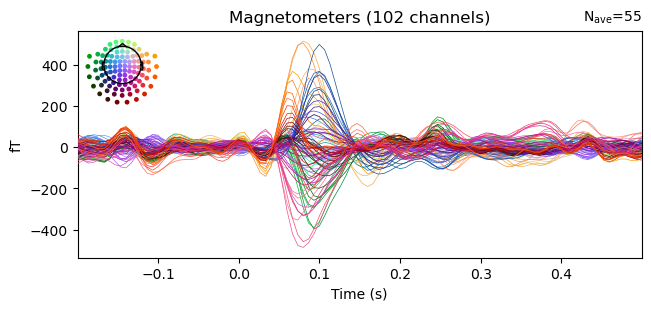

In [4]:
erf = epochs["auditory/left"].average()
erf.plot();

**Exercise**: Compute and plot the ERF for all `"auditory/right"` epochs.

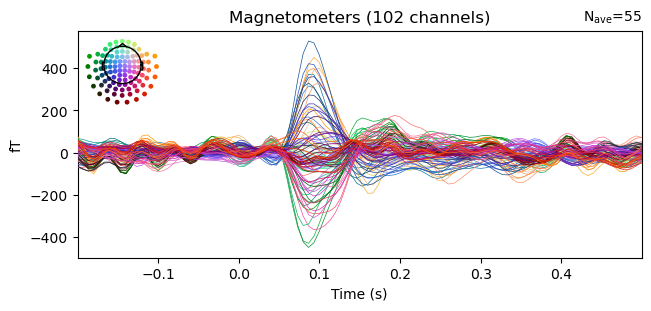

In [5]:
erf = epochs["auditory/right"].average()
erf.plot();

There clearly is a difference between the responses to auditory stimuli to the left and right ears. To compare those responses we first have to compute the ERF for every condition. Run the cell below to compute the ERFs with `by_event_type=True` and convert the result to a dictionary. We can index the resulting dictionary of `erfs` like we did with the epochs.

In [6]:
erfs = epochs.average(by_event_type=True)
erfs = {e.comment: e for e in erfs}
erfs


{'auditory/left': <Evoked | 'auditory/left' (average, N=55), -0.1998 – 0.49949 s, baseline off, 102 ch, ~3.1 MiB>,
 'auditory/right': <Evoked | 'auditory/right' (average, N=55), -0.1998 – 0.49949 s, baseline off, 102 ch, ~3.1 MiB>,
 'visual/left': <Evoked | 'visual/left' (average, N=55), -0.1998 – 0.49949 s, baseline off, 102 ch, ~3.1 MiB>,
 'visual/right': <Evoked | 'visual/right' (average, N=55), -0.1998 – 0.49949 s, baseline off, 102 ch, ~3.1 MiB>}

**Example**: Use the `combine_evoked()` function with `weights=[1, -1]` to subtract the ERFs for the `"auditory/left"` and `"auditory/right"` conditions and use the `.plot_joint()` method to visualize the difference.

Projections have already been applied. Setting proj attribute to True.


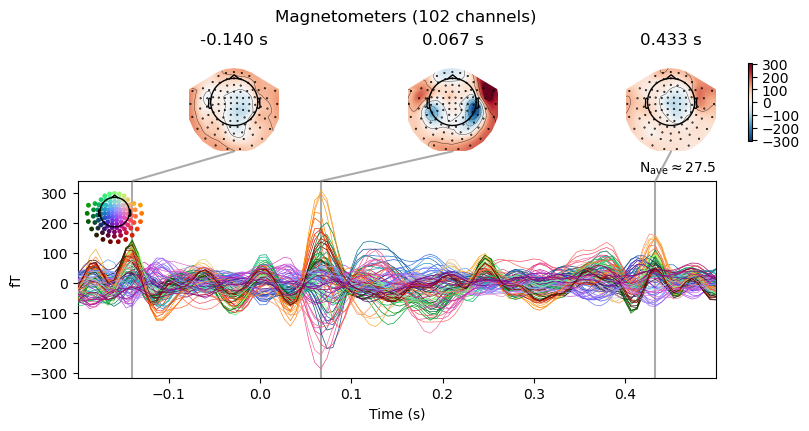

In [7]:
erf_diff = mne.combine_evoked( 
    [erfs["auditory/left"], erfs["auditory/right"]],
    weights=[1, -1]
    )
erf_diff.plot_joint();

**Exercise**: Use the `combine_evoked()` function with `weights=[1, -1]` to subtract the ERFs for the `"visual/left"` and `"visual/right"` conditions and use the `.plot_joint()` method to visualize the difference.

Which region shows the largest difference ERF?

Projections have already been applied. Setting proj attribute to True.


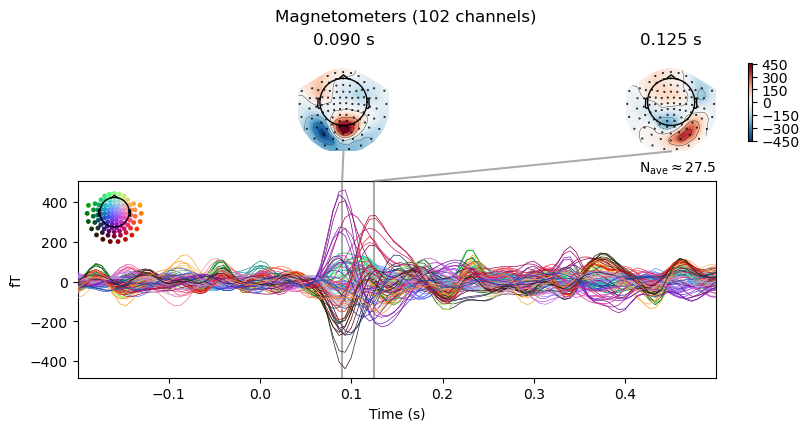

In [8]:
erf_diff = mne.combine_evoked( 
    [erfs["visual/left"], erfs["visual/right"]],
    weights=[1, -1]
    )
erf_diff.plot_joint(times=[0.09, 0.125]);

**Example**: Compare the ERFs of the `"auditory/left"` and `"auditory/right"` at the channel `["MEG 1411"]`. This channel is located over the right temporal region and picks up activity generated in the right auditory cortex.
Which stimulus produces a larger response at this channel?

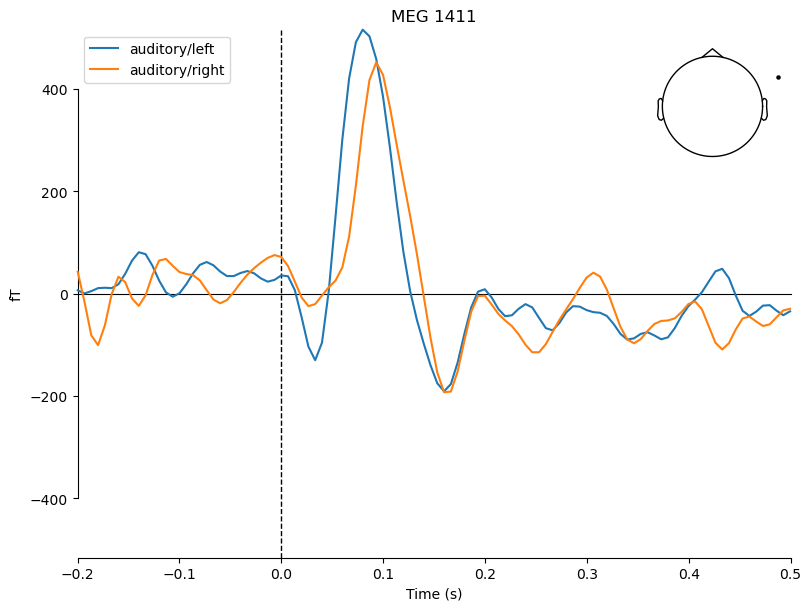

In [9]:
mne.viz.plot_compare_evokeds(
    [erfs["auditory/left"], erfs["auditory/right"]],
    picks=["MEG 1411"]
    );

**Exercise**: Compare the ERFs of the `"visual/left"` and `"visual/right"` at the channel `["MEG 1731"]`. This channel is located over the left occipital region and picks up activity generated in the left visual cortex.
How does the left/right asymmetry of the visual response compare to the auditory response from the previous example?

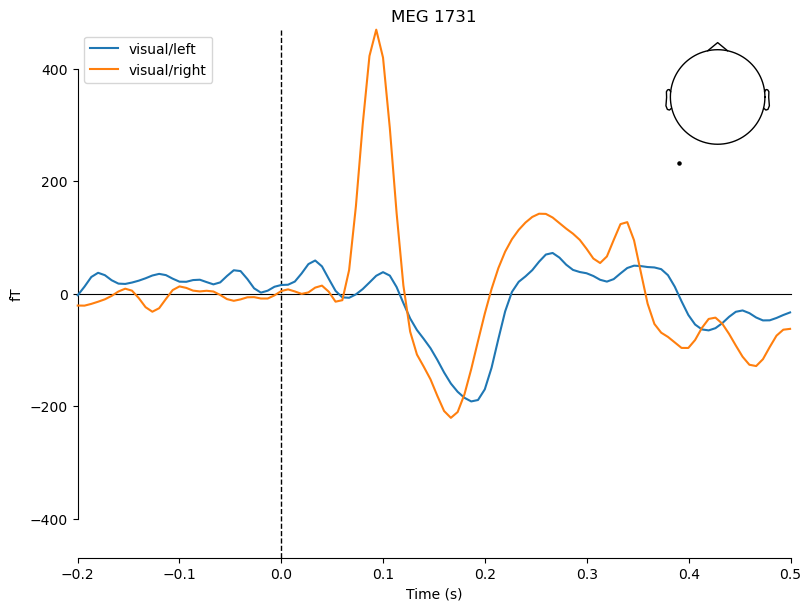

In [10]:
mne.viz.plot_compare_evokeds(
    [erfs["visual/left"], erfs["visual/right"]],
    picks=["MEG 1731"]
    );

## Statistical Comparison of ERFs

### Background

The **one-sample t-test** tests whether the mean of a sample is significantly different from a reference value — in our case, whether the mean difference between two conditions is different from zero. The **t-statistic** is computed as:

$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$

where $\bar{x}$ is the sample mean, $\mu_0$ is the reference value (here 0), $s$ is the sample standard deviation, and $n$ is the number of observations (trials). The t-statistic therefore measures how many standard errors the mean is away from zero.  The **p-value** is the probability of observing a t-statistic at least as extreme as the measured one, under the null hypothesis. By convention, effects with $p < 0.05$ are considered statistically significant.

By computing a t-test at every time point, we obtain a t-value time course that shows *when* the two conditions diverge. Extending this to all channels gives a t-value and p-value for every channel and time point, which can be visualized as a topographic map to show *where* the effect is significant.

### Exercises

In the following exercises, you will extract epoch data as NumPy arrays, compute t-tests at single channels and across all channels, and visualize the results as time courses and topographic maps. Here are the code snippets you will need:

| Code | Description |
| --- | --- |
| `epochs["condition"].get_data(picks=["MEG 0611"])` | Extract epoch data as an array of shape `(n_epochs, n_channels, n_times)` |
| `diff.mean(axis=0).T` | Average the difference across epochs and transpose for plotting |
| `t, p = ttest_1samp(diff, popmean=0)` | Compute t- and p-values testing whether the mean difference is different from zero |
| `plt.fill_between(epochs.times, ymin, ymax, where=mask, alpha=0.2)` | Shade time windows where `mask` is `True` |
| `(p < p_thresh).any(axis=0)` | Boolean mask that is `True` at time points where any channel is significant |
| `idx = np.argmin(np.abs(epochs.times - time))` | Find the index of the time point closest to `time` seconds |
| `mne.viz.plot_topomap(t[:, idx], epochs.info, mask=p[:, idx] < p_thresh)` | Plot a topographic map of t-values with significant channels marked |

**Example**: Get the data for all epochs in the `"auditory/left"` and `"auditory/right"` conditions at the central channel `"MEG 0611"`, compute their difference and plot the average difference.

Hint: `diff.mean(axis=0).T` averages the difference across epochs and transposes the result so it can be passed to `plt.plot()`.

Text(0.5, 0, 'Time [s]')

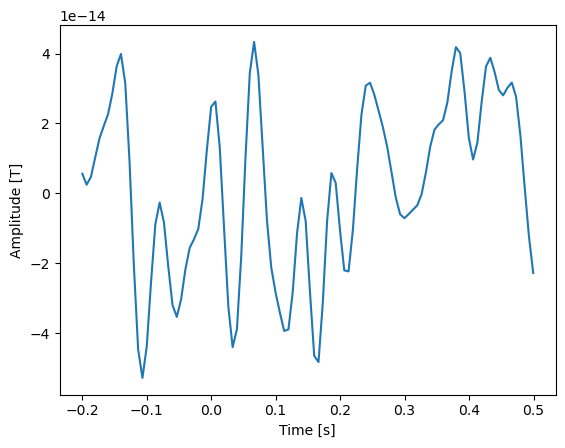

In [11]:
data_aud_l = epochs["auditory/left"].get_data(picks=["MEG 0611"])
data_aud_r = epochs["auditory/right"].get_data(picks=["MEG 0611"])
diff = data_aud_l - data_aud_r

plt.plot(epochs.times, diff.mean(axis=0).T)
plt.ylabel("Amplitude [T]")
plt.xlabel("Time [s]")

**Exercise**: Get the data for all epochs in the `"auditory/left"` and `"auditory/right"` conditions at the right temporal channel `["MEG 1411"]`, compute their difference and plot the average difference.

Text(0.5, 0, 'Time [s]')

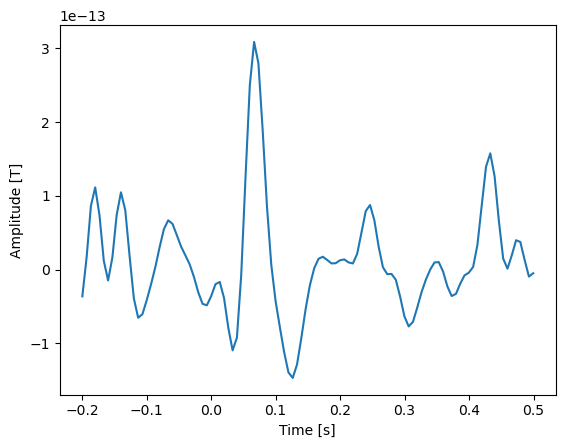

In [12]:
data_aud_l = epochs["auditory/left"].get_data(picks=["MEG 1411"])
data_aud_r = epochs["auditory/right"].get_data(picks=["MEG 1411"])
diff = data_aud_l - data_aud_r

plt.plot(epochs.times, diff.mean(axis=0).T)
plt.ylabel("Amplitude [T]")
plt.xlabel("Time [s]")

**Example**: Perform a t-test to test whether the difference is significantly different from 0 at every point in time and plot the resulting t-values across time.

How does this curve compare to the average difference between the conditions from the previous exercise?

Text(0.5, 0, 'Time [s]')

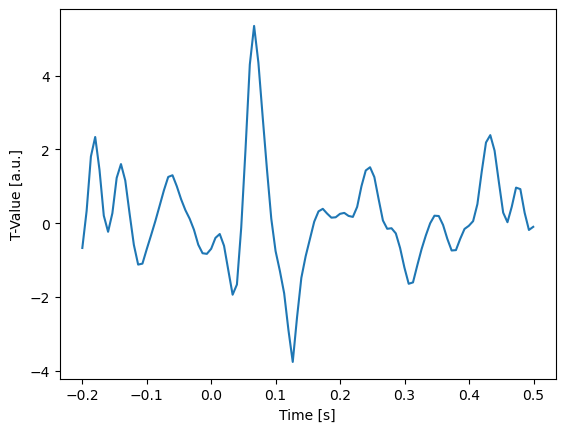

In [13]:
t, p = ttest_1samp(diff, popmean=0)

plt.plot(epochs.times, t.T)
plt.ylabel("T-Value [a.u.]")
plt.xlabel("Time [s]")

**Exercise**: The cell below computes the difference between epochs in the `"visual/left"` and `"visual/right"` conditions. Perform a t-test to test whether the difference is significantly different from 0 and plot the t-values across time.

In [14]:
data_vis_l = epochs["visual/left"].get_data(picks=["MEG 1731"])
data_vis_r = epochs["visual/right"].get_data(picks=["MEG 1731"])
diff = data_vis_l - data_vis_r

Text(0.5, 0, 'Time [s]')

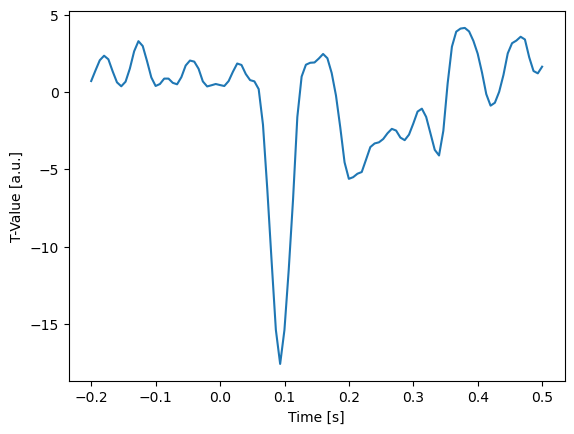

In [15]:
t, p = ttest_1samp(diff, popmean=0)

plt.plot(epochs.times, t.T)
plt.ylabel("T-Value [a.u.]")
plt.xlabel("Time [s]")

**Example**: Plot the t-values and highlight times where the p-value is lower than `p_thresh=0.05` in red.

Hint: `(p < p_thresh).any(axis=0)` checks if the p-value at ANY channel is smaller than the threshold.

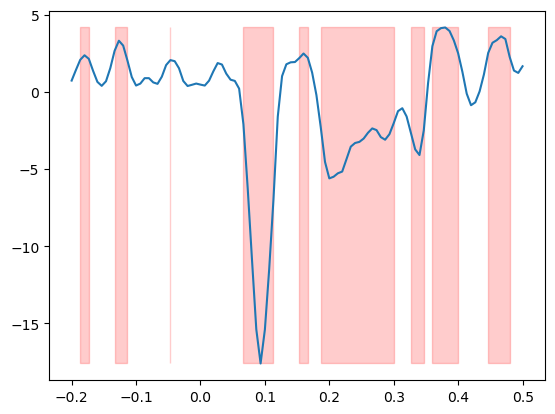

In [16]:
p_thresh= 0.05
plt.plot(epochs.times, t.T)
plt.fill_between(epochs.times, t.min(), t.max(), where=(p < p_thresh).any(axis=0), alpha=0.2, color="r")

**Exercise**: Plot the t-values and highlight times where the p-value is lower than `0.001` in red.

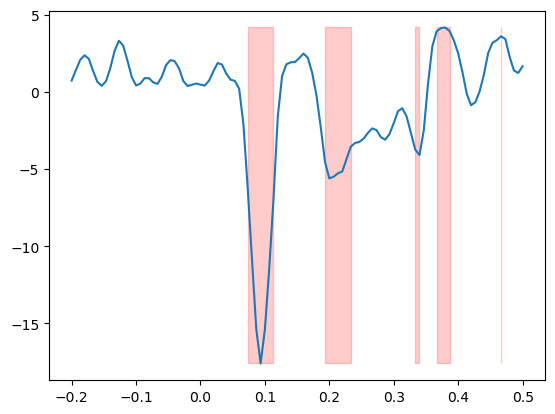

In [17]:
p_thresh= 0.001
plt.plot(epochs.times, t.T)
plt.fill_between(epochs.times, t.min(), t.max(), where=(p < p_thresh).any(axis=0), alpha=0.2, color="r")

The cell below computes the difference between the `"visual/left"` and `"visual/right"` conditions for ALL channels and runs a t-test. This gives us a t-value and p-value for every channel and time point.

In [18]:
data_vis_l = epochs["visual/left"].get_data()
data_vis_r = epochs["visual/right"].get_data()
diff = data_vis_l - data_vis_r
t, p = ttest_1samp(diff, popmean=0)
t.shape, p.shape

((102, 106), (102, 106))

**Example**: Plot the topographical distribution of t-values at `time=0.05` seconds and mask all channels where the p-value is smaller than `0.05`.

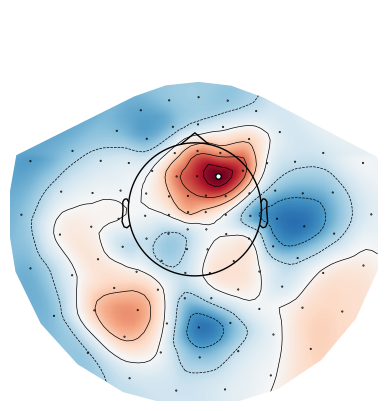

In [19]:
time = 0.05
p_thresh = 0.05
idx = np.argmin(np.abs(epochs.times-time))
mne.viz.plot_topomap(t[:, idx], epochs.info, size=4, mask=p[:,idx]<p_thresh);

**Exercise**: Plot the topographical distribution of t-values at `time=0.1` seconds and mask all channels where the p-value is smaller than `0.001`.

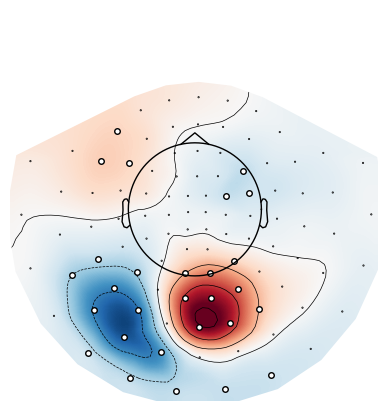

In [20]:
time = 0.1
p_thresh = 0.001
idx = np.argmin(np.abs(epochs.times-time))
mne.viz.plot_topomap(t[:, idx], epochs.info, size=4, mask=p[:,idx]<p_thresh);

**Exercise**: How low would you have to set `p_thresh` to only mask the channels that cover the prominent dipole over the occipital region?

Note: This is just for demonstration purposes, p-values should always be selected **independently of the data**!

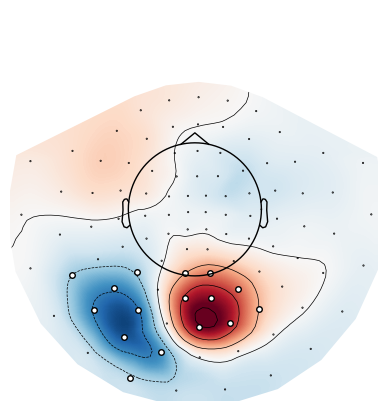

In [21]:
time = 0.1
p_thresh = 0.00001
idx = np.argmin(np.abs(epochs.times-time))
mne.viz.plot_topomap(t[:, idx], epochs.info, size=4, mask=p[:,idx]<p_thresh);

## Correcting for Multiple Comparisons

### Background

When performing a statistical test at every time point and channel, the probability of obtaining at least one false positive increases with the number of tests. If we conduct $m$ independent tests each at significance level $\alpha$, the probability of at least one false positive across all tests is $1 - (1 - \alpha)^m$, which approaches 1 as $m$ grows large.

The **Bonferroni correction** controls the **family-wise error rate** (FWER) — the probability of making even a single false positive across all tests — by dividing the significance threshold by the number of tests:

$$\alpha_{\text{corrected}} = \frac{\alpha}{m}$$

This guarantees that the probability of any false positive is at most $\alpha$, regardless of how many tests are performed. The correction becomes increasingly strict as $m$ grows: with 102 channels and 106 time points, the corrected threshold is $\alpha / 10812 \approx 4.6 \times 10^{-6}$, meaning only very strong effects will survive.

### Exercises

In the following exercises, you will apply the Bonferroni correction to the p-values from the previous section and visualize how the corrected threshold changes with the number of tests. Here are the code snippets you will need:

| Code | Description |
| --- | --- |
| `_, p_corr = mne.stats.bonferroni_correction(p)` | Apply Bonferroni correction to an array of p-values |
| `p_thresh_corrected = p_thresh / (n_channels * n_timepoints)` | Compute the Bonferroni-corrected threshold manually |
| `bins = np.logspace(np.log10(p.min()), 0, 50)` | Create logarithmically spaced bin edges for a p-value histogram |

The code below tests the difference between the `"auditory/left"` and `"auditory/right"` conditions at the right temporal channel `"MEG 1441"` and plots the t-values while highlighting all samples where the **uncorrected** p-value is smaller than `0.05`.

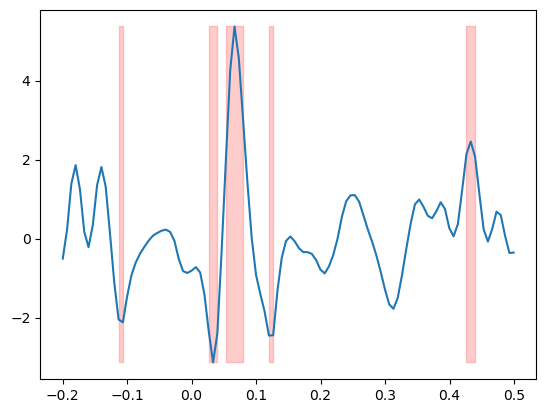

In [22]:
data_aud_l = epochs["auditory/left"].get_data(picks=["MEG 1441"])
data_aud_r = epochs["auditory/right"].get_data(picks=["MEG 1441"])
diff = data_aud_l - data_aud_r
t, p = ttest_1samp(diff, popmean=0)

p_thresh = 0.05
plt.plot(epochs.times, t.T)
plt.fill_between(epochs.times, t.min(), t.max(), where=(p < p_thresh).any(axis=0), alpha=0.2, color="r")

**Exercise**: Apply the `bonferroni_correction` to the p-values then plot the t-values and highlight all samples where the Bonferroni-corrected p-value is smaller than `0.05`.

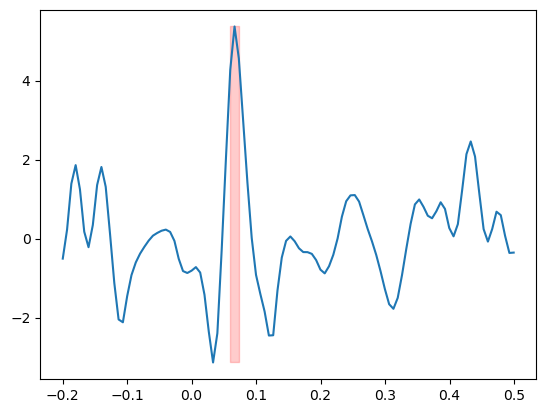

In [23]:
_, p_corr = mne.stats.bonferroni_correction(p)
plt.plot(epochs.times, t.T)
plt.fill_between(epochs.times, t.min(), t.max(), where=(p_corr < p_thresh).any(axis=0), alpha=0.2, color="r")

**Exercise**: The code below tests the difference between `"auditory/left"` and `"auditory/right"` for all channels. Apply the `bonferroni_correction` and plot the topographic map of t-values at `time=0.08` while masking all channels where the Bonferroni-corrected p-value is lower than `0.05`.

In [24]:
data_aud_l = epochs["auditory/left"].get_data()
data_aud_r = epochs["auditory/right"].get_data()
diff = data_aud_l - data_aud_r
t, p = ttest_1samp(diff, popmean=0)

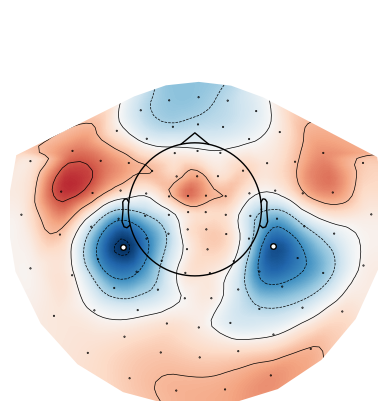

In [25]:
_, p_corr = mne.stats.bonferroni_correction(p)
time = 0.08
p_thresh = 0.05
idx = np.argmin(np.abs(epochs.times-time))
mne.viz.plot_topomap(t[:, idx], epochs.info, size=4, mask=p_corr[:,idx]<p_thresh);

**Exercise**: The code below plots the distribution of p-values and marks both the uncorrected and Bonferroni-corrected thresholds. Increase `n_channels` and `n_timepoints` to reflect more realistic numbers of tests and observe how the corrected threshold changes and how many results survive.

Note: The hemispheric asymmetry for unilateral auditory stimuli is a very strong effect and may survive even very strict corrections.

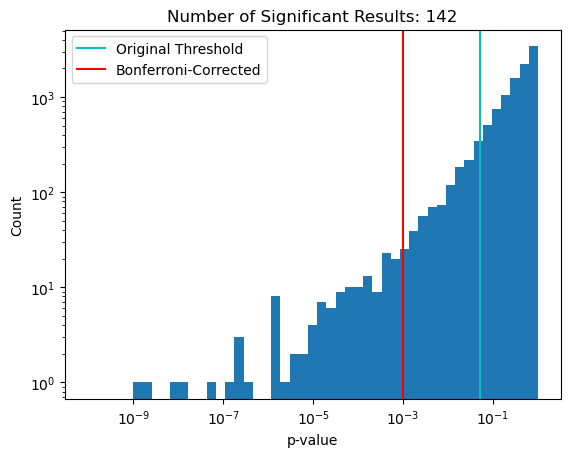

In [26]:
n_channels = 1
n_timepoints = 50
p_thresh = 0.05
p_thresh_adjusted = p_thresh / (n_channels * n_timepoints)

bins = np.logspace(np.log10(p.min()), 0, 50)
plt.hist(p.flatten(), bins=bins)
plt.axvline(p_thresh, color="c", label="Original Threshold")
plt.axvline(p_thresh_adjusted, color="r", label="Bonferroni-Corrected")
plt.xscale("log")
plt.xlabel("p-value")
plt.ylabel("Count")
plt.yscale("log")
plt.title(f"Number of Significant Results: {(p.flatten()<p_thresh_adjusted).sum()}")
plt.legend()



## Permutation Cluster Test

### Background

The **permutation cluster test** is a non-parametric approach that exploits the spatial and temporal structure of the data. Rather than testing each time point and channel independently, it groups adjacent significant time points and channels into **clusters** and assesses their significance as a whole. By assessing the cluster as a whole, the permutation cluster test avoids the multiple comparisons problem entirely (see [Maris & Oostenveld, 2007](https://www.sciencedirect.com/science/article/abs/pii/S0165027007001707?via%3Dihub)). The procedure has three steps:

1. **Form clusters**: compute t-statistics at each time point and channel and group adjacent elements that exceed a threshold into clusters. The sum of the t-values within a cluster is the cluster statistic.
2. **Estimate the null distribution**: randomly shuffle the trials between conditions and find the largest cluster in the shuffled data. Repeat this across many permutations to get the distribution of maximum cluster statistics under the null hypothesis.
3. **Compute cluster p-values**: the p-value is the proportion of permutations in which the maximum null cluster statistic was at least as large as the observed cluster statistic. A small p-value means that a cluster of the given size is unlikely under randomly shuffled data.

Once we have established the significance of a cluster, we can visualize its spatial and temporal extent to link it to the underlying neural phenomena.

### Exercises

In the following exercises, you will run the spatio-temporal permutation cluster test to compare two conditions across all channels and time points, and visualize the significant clusters. Here are the code snippets you will need:

| Code | Description |
| --- | --- |
| `X = [data_l.transpose(0, 2, 1), data_r.transpose(0, 2, 1)]` | Prepare data as a list of arrays with shape `(n_epochs, n_times, n_channels)` |
| `adjacency, _ = mne.channels.find_ch_adjacency(epochs.info, ch_type="mag")` | Compute the channel adjacency matrix for spatial clustering |
| `n = data_l.shape[0] + data_r.shape[0]` | Total number of observations across both conditions |
| `threshold = t_dist.ppf(1 - 0.05/2, df=n-2)` | t-value threshold for cluster formation (p=0.05, two-tailed) |
| `t, clusters, p, _ = mne.stats.spatio_temporal_cluster_test(X, n_permutations=1000, threshold=t_thresh, adjacency=adjacency, stat_fun=mne.stats.ttest_ind_no_p, seed=42)` | Run the spatio-temporal permutation cluster test |
| `idx = np.argsort(p)[0]` | Find the index of the most significant cluster |
| `utils.plot_cluster_topo(clusters[idx], t, p[idx], epochs)` | Plot the topographic map of averaged t-values for a cluster |
| `utils.plot_cluster_channels(clusters[idx], p[idx], erf)` | Plot the ERF time courses of a cluster's channels with the cluster window highlighted |

To run the cluster test we have to prepare a list `X` that contains the epochs for the conditions we want to compare. Because the `spatio_temporal_cluster_test()` function expects the data to be shaped `(n_epochs, n_times, n_channels)` we have to `.transpose()` the array.

In [27]:
data_aud_l = epochs["auditory/left"].get_data()
data_aud_r = epochs["auditory/right"].get_data()
X = [data_aud_l.transpose(0, 2, 1), data_aud_r.transpose(0, 2, 1)]


The cluster test needs to know which channels count as adjacent. We can use the `find_ch_adjacency()` function to get this information and plot the adjacency matrix.

Reading adjacency matrix for neuromag306mag.


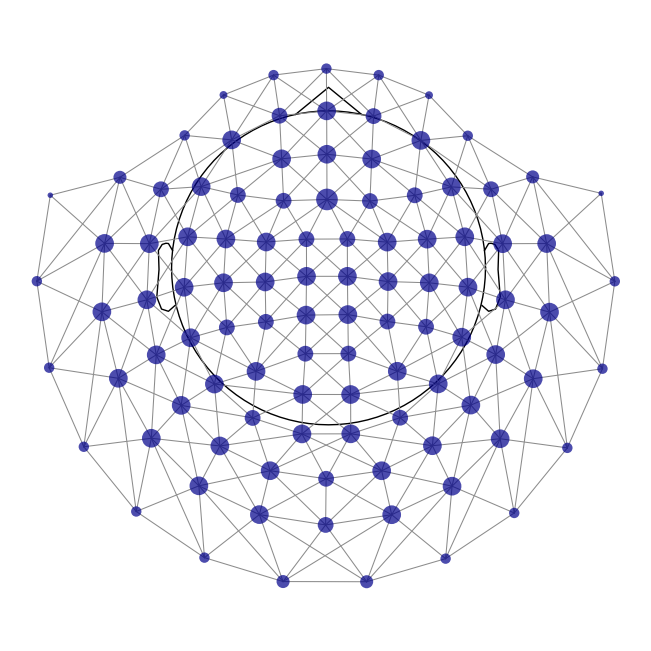

In [28]:
adjacency, ch_names = mne.channels.find_ch_adjacency(epochs.info, ch_type="mag")
mne.viz.plot_ch_adjacency(epochs.info, adjacency, ch_names);

Finally, we need to set a t-value threshold: times and channels where the t-value exceeds the threshold will be grouped into clusters. Here, we choose the value from the t-distribution `t_dist` that corresponds to a p-value of `p=0.01`.

In [29]:
p_thresh = 0.01
n = data_aud_l.shape[0] + data_aud_r.shape[0]
t_thresh = t_dist.ppf(1 - p_thresh / 2, df=n - 2)

**Example**: Run the `spatio_temporal_cluster_test()` on the list of epochs `X` with `100` permutations using the `ttest_ind_no_p()` function as `stat_fun`. Then print the smallest p-value.

In [30]:
t, clusters, p, _= mne.stats.spatio_temporal_cluster_test(
    X,
    n_permutations=100,
    threshold=t_thresh,
    adjacency=adjacency,
    stat_fun=mne.stats.ttest_ind_no_p,
    seed=42
)
p.min()

stat_fun(H1): min=-7.8487696973852 max=5.745549017832594
Running initial clustering …
Found 37 clusters


  0%|          | Permuting : 0/99 [00:00<?,       ?it/s]

np.float64(0.01)

**Exercise**: Run the `spatio_temporal_cluster_test()` again but increase the number of permutations to `1000` and print the smallest p-value. Why does increasing the number of permutations change the p-value?

In [31]:
t, clusters, p, _= mne.stats.spatio_temporal_cluster_test(
    X,
    n_permutations=1000,
    threshold=t_thresh,
    adjacency=adjacency,
    stat_fun=mne.stats.ttest_ind_no_p,
    seed=42
)
p.min()

stat_fun(H1): min=-7.8487696973852 max=5.745549017832594
Running initial clustering …


Found 37 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

np.float64(0.007)

**Example**: Get the index of the cluster with the smallest p-value and visualize the cluster using the `utils.plot_cluster_topo()` function. The topographical plot shows the t-value of each channel, averaged across the cluster duration.

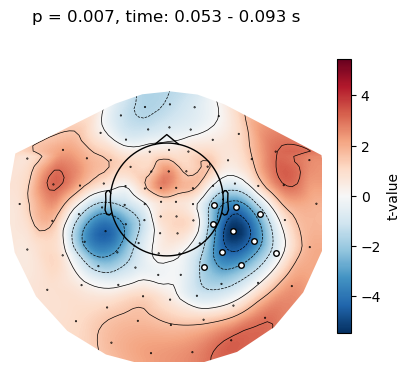

In [32]:
idx = np.argsort(p)[0]
utils.plot_cluster_topo(clusters[idx], t, p[idx], epochs)

**Exercise**: Get the index of the cluster with the second smallest p-value and visualize the cluster using the `utils.plot_cluster_topo()` function.

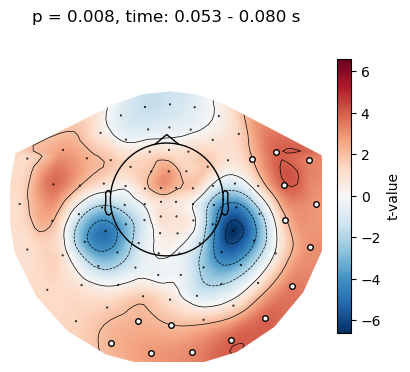

In [33]:
idx = np.argsort(p)[1]
utils.plot_cluster_topo(clusters[idx], t, p[idx], epochs)

**Example**: Get the index of the cluster with the smallest p-value, compute the difference ERF between the `"auditory/left"` and `"auditory/right"` conditions and visualize it using `utils.plot_cluster_channels()` which marks the temporal extent of the cluster.

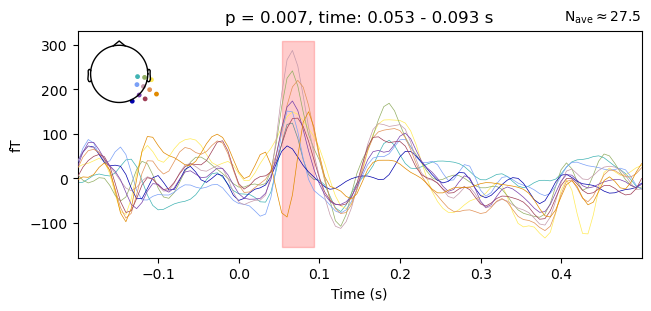

In [34]:
idx = np.argsort(p)[0]
diff = mne.combine_evoked([erfs["auditory/left"], erfs["auditory/right"]], weights=(-1, 1))
utils.plot_cluster_channels(clusters[idx], p[idx], diff)

**Exercise**: Get the index of the cluster with the second smallest p-value and visualize the difference ERF using `utils.plot_cluster_channels()`.

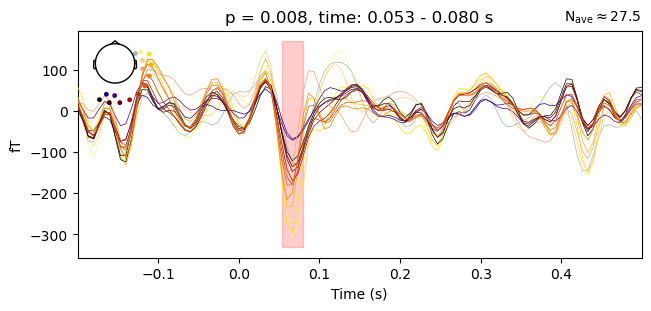

In [35]:
idx = np.argsort(p)[1]
utils.plot_cluster_channels(clusters[idx], p[idx], diff)

The t-value threshold determines the spatial and temporal sensitivity of the cluster test. With a lower threshold, the sensitivity is higher but clusters are more spread out. Let's increase the threshold to the t-value that corresponds to `p_thresh=0.0001`.

Note: The cluster test establishes only the significance of the cluster as a whole, not the precise latency or location of the effect, see [Sassenhagen & Draschkow, 2019](https://pubmed.ncbi.nlm.nih.gov/30657176/).

In [36]:
p_thresh = 0.0001
n = data_aud_l.shape[0] + data_aud_r.shape[0]
t_thresh = t_dist.ppf(1 - p_thresh / 2, df=n - 2)
t_thresh

np.float64(4.040874280449325)

**Exercise**: Run the `spatio_temporal_cluster_test` again with `1000` permutations using the new `t_thresh`.

In [37]:
t, clusters, p, _= mne.stats.spatio_temporal_cluster_test(
    X,
    n_permutations=1000,
    threshold=t_thresh,
    adjacency=adjacency,
    stat_fun=mne.stats.ttest_ind_no_p,
    seed=42
)

stat_fun(H1): min=-7.8487696973852 max=5.745549017832594
Running initial clustering …
Found 8 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

**Exercise**: Use `utils.plot_cluster_topo` and `utils.plot_cluster_channels` again to visualize the spatial and temporal extent of the cluster with the second lowest p-value. How does it compare to the previous cluster?

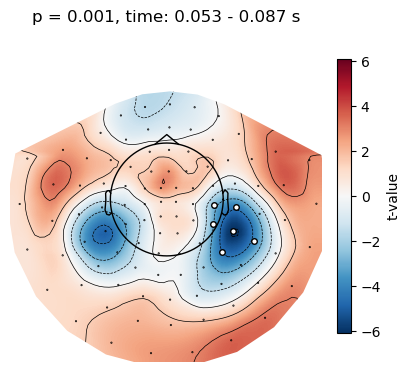

In [38]:
idx = np.argsort(p)[1]
utils.plot_cluster_topo(clusters[idx], t, p[idx], epochs)

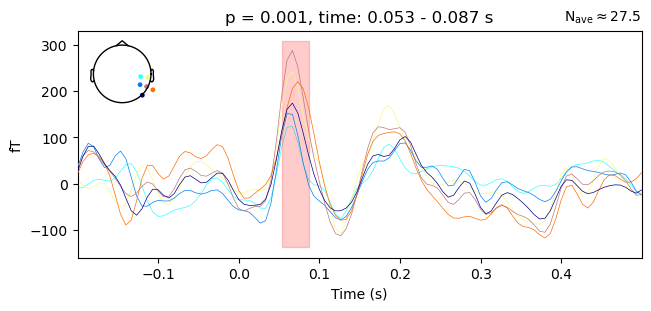

In [39]:
idx = np.argsort(p)[1]
utils.plot_cluster_channels(clusters[idx], p[idx], diff)

**Bonus**: Put everything together: run the `spatio_temporal_cluster_test` to compare the responses to the `"visual/left"` and `"visual/right"` conditions and plot the results.

In [40]:
data_vis_l = epochs["visual/left"].get_data()
data_vis_r = epochs["visual/right"].get_data()
X = [data_vis_l.transpose(0, 2, 1), data_vis_r.transpose(0, 2, 1)]

t, clusters, p, _= mne.stats.spatio_temporal_cluster_test(
    X,
    n_permutations=100,
    tail=1,
    threshold=t_thresh,
    adjacency=adjacency,
    stat_fun=mne.stats.ttest_ind_no_p,
    seed=42
)

stat_fun(H1): min=-19.195299893597486 max=19.313787724127813
Running initial clustering …
Found 8 clusters


  0%|          | Permuting : 0/99 [00:00<?,       ?it/s]

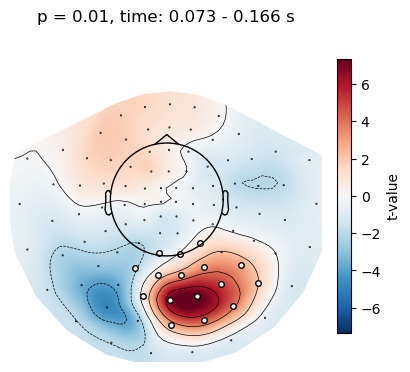

In [41]:
idx = np.argsort(p)[0]
utils.plot_cluster_topo(clusters[idx], t, p[idx], epochs)

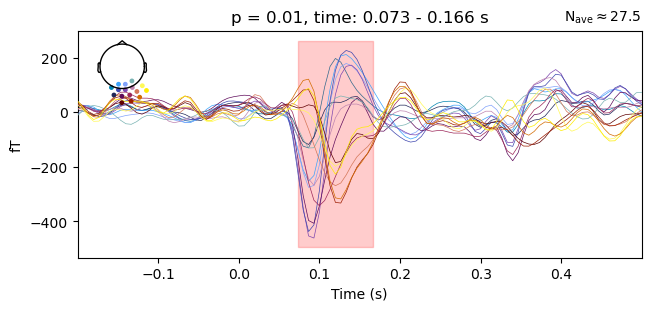

In [42]:
idx = np.argsort(p)[0]
diff = mne.combine_evoked([erfs["visual/left"], erfs["visual/right"]], weights=[-1, 1])
utils.plot_cluster_channels(clusters[idx], p[idx], diff)